In this notebook we want to show this narrative:
- Try 3-5 different pre-trained models initially using the same architecture and just changing the model
- Compare results and select the best performing one
- Fine-tune a smaller version of the model and compare performance a bigger version without fine-tuning

# Pre-trained models

## 0. Imports and GPU config

In [1]:
import sys
sys.path.append('../src')

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import keras
from keras import layers

from utils import plot_model_history

2026-04-21 16:13:40.627814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776784420.655929   72396 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776784420.667161   72396 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776784420.765423   72396 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776784420.765457   72396 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776784420.765459   72396 computation_placer.cc:177] computation placer alr

Check if our GPU is detected

In [2]:
gpus = tf.config.list_physical_devices('GPU')
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Configure memory limit to take advantage of all of our VRAM

In [3]:
for gpu in gpus:
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=round(3.8*1024))]
    )

## 1. Data import

In [4]:
image_size = (512, 512) # use original image size
input_shape = image_size + (3,)
batch_size = 4 # use a smaller value since we are using a bigger resolution
n_classes = 23

train_ds = keras.utils.image_dataset_from_directory(
    "../Data/Train",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = keras.utils.image_dataset_from_directory(
    "../Data/Validation",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

test_ds = keras.utils.image_dataset_from_directory(
    "../Data/Test",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical"
)

Found 9338 files belonging to 23 classes.


I0000 00:00:1776784426.947851   72396 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3891 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 2001 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.


## 2. VGG16

<img src="../images/vgg16.png" width="50%"/>

VGG16 was developed in Oxford University and it is a simple but big model in terms of parameters. It just stacks 3x3 convolutional layers followed by max pooling layers, in four blocks and ends with three fully connected layers. It has a big parameter count because of the big fully connected layers at the end and the flatten layer, so it is not very parameter efficient.

check if it valid to pass our own image size, or if it is better to use the default values from each model

check if it is better to pass the correct number of classes to the base model or not

In [5]:
vgg16_base_model = keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    # input_shape=input_shape,
    classes=23
)

vgg16_base_model.trainable = False

In [51]:
inputs = keras.Input(shape=input_shape)

# try resizing the image to the default image size of VGG16
# x = layers.Resizing(224, 224)(inputs)

# try augmentation
x = layers.Pipeline(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(factor=0.08),
        layers.RandomContrast(factor=0.08),
        layers.RandomRotation(factor=0.02, fill_mode="reflect"),
        layers.RandomZoom((-0.05, 0.05), fill_mode="reflect"),
        layers.RandomTranslation(
            height_factor=0.05, width_factor=0.05, fill_mode="reflect"
        ),
        layers.GaussianNoise(stddev=0.02),
    ],
    name="augmentation_moderate_noise",
)(inputs)

# apply VGG16 preprocessing
# The images are converted from RGB to BGR, then each color channel 
# is zero-centered with respect to the ImageNet dataset, without scaling.
x = keras.applications.vgg16.preprocess_input(x)

x = vgg16_base_model(x, training=False)

# x = layers.Flatten()(x) 
# use Flatten like VGG16 originally
# we experimented also with GlobalAveragePooling to reduce the number of trainable params
x = layers.GlobalAveragePooling2D()(x)

# try dropout
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(n_classes, activation="softmax")(x)


vgg16_pre_trained_model = keras.Model(inputs=inputs, outputs=outputs, name="vgg16_pre_trained")

In [52]:
vgg16_pre_trained_model.summary()

Model: "vgg16_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation_moder… │ (None, 512, 512,  │          0 │ input_layer_13[0… │
│ (Pipeline)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_33         │ (None, 512, 512)  │          0 │ augmentation_mod… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_34         │ (None, 512, 512)  │          0 │ augmentation_mod… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_35         │ (None, 512, 512)  │          0 │ augmentation_mod… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_11 (Stack)    │ (None, 512, 512,  │          0 │ get_item_33[0][0… │
│                     │ 3)                │            │ get_item_34[0][0… │
│                     │                   │            │ get_item_35[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 512, 512,  │          0 │ stack_11[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 16, 16,    │ 14,714,688 │ add_11[0][0]      │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[11][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 512)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 23)        │     11,799 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,726,487 (56.18 MB)

 Trainable params: 11,799 (46.09 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

using image size (512, 512), 0.2 dropout, moderate noise augmentation, global avg pooling

In [53]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [54]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 612s 260ms/step - categorical_accuracy: 0.4586 - f1_score: 0.4210 - loss: 2.1895 - val_categorical_accuracy: 0.6392 - val_f1_score: 0.6177 - val_loss: 1.3433
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 611s 262ms/step - categorical_accuracy: 0.6266 - f1_score: 0.5977 - loss: 1.3594 - val_categorical_accuracy: 0.6962 - val_f1_score: 0.6715 - val_loss: 1.1442
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 615s 263ms/step - categorical_accuracy: 0.6544 - f1_score: 0.6320 - loss: 1.2418 - val_categorical_accuracy: 0.7031 - val_f1_score: 0.6797 - val_loss: 1.1420
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 603s 258ms/step - categorical_accuracy: 0.6809 - f1_score: 0.6592 - loss: 1.1824 - val_categorical_accuracy: 0.6932 - val_f1_score: 0.6743 - val_loss: 1.2086


using image size (224, 224), 0.2 dropout, moderate noise augmentation, global avg pooling

In [49]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [50]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.3870 - f1_score: 0.3576 - loss: 3.1570 - val_categorical_accuracy: 0.5537 - val_f1_score: 0.5157 - val_loss: 2.4349
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 153s 65ms/step - categorical_accuracy: 0.5425 - f1_score: 0.5197 - loss: 1.9773 - val_categorical_accuracy: 0.5957 - val_f1_score: 0.5693 - val_loss: 1.9901
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 155s 66ms/step - categorical_accuracy: 0.5749 - f1_score: 0.5526 - loss: 1.8195 - val_categorical_accuracy: 0.5847 - val_f1_score: 0.5627 - val_loss: 2.2339


using image size (224, 224), 0.5 dropout, moderate noise augmentation, global avg pooling

In [45]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [46]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 148s 63ms/step - categorical_accuracy: 0.3025 - f1_score: 0.2749 - loss: 4.5527 - val_categorical_accuracy: 0.5302 - val_f1_score: 0.4874 - val_loss: 2.4021
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.4324 - f1_score: 0.4066 - loss: 2.8519 - val_categorical_accuracy: 0.5652 - val_f1_score: 0.5311 - val_loss: 2.2426
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.4597 - f1_score: 0.4358 - loss: 2.5847 - val_categorical_accuracy: 0.5792 - val_f1_score: 0.5504 - val_loss: 2.1201
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.4662 - f1_score: 0.4431 - loss: 2.5733 - val_categorical_accuracy: 0.5777 - val_f1_score: 0.5443 - val_loss: 2.1205


using image size (224, 224), 0.5 dropout, moderate noise augmentation, flatten with one more dense layer

In [41]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [42]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 162s 65ms/step - categorical_accuracy: 0.3903 - f1_score: 0.3651 - loss: 48.6879 - val_categorical_accuracy: 0.4873 - val_f1_score: 0.4371 - val_loss: 17.0910
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 156s 67ms/step - categorical_accuracy: 0.4913 - f1_score: 0.4657 - loss: 10.9770 - val_categorical_accuracy: 0.4643 - val_f1_score: 0.4081 - val_loss: 14.8993


using image size (224, 224), 0.5 dropout, moderate noise augmentation, flatten

In [37]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [38]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 64ms/step - categorical_accuracy: 0.4225 - f1_score: 0.3980 - loss: 41.9377 - val_categorical_accuracy: 0.5557 - val_f1_score: 0.5295 - val_loss: 47.6201
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 64ms/step - categorical_accuracy: 0.5771 - f1_score: 0.5579 - loss: 40.3491 - val_categorical_accuracy: 0.5907 - val_f1_score: 0.5649 - val_loss: 57.1677
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.6381 - f1_score: 0.6227 - loss: 37.9426 - val_categorical_accuracy: 0.6097 - val_f1_score: 0.5829 - val_loss: 67.4209
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.6770 - f1_score: 0.6637 - loss: 35.4321 - val_categorical_accuracy: 0.5892 - val_f1_score: 0.5622 - val_loss: 79.4678


using image size (224, 224), 0.2 dropout, moderate noise augmentation, flatten

In [33]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [34]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10


2335/2335 ━━━━━━━━━━━━━━━━━━━━ 148s 62ms/step - categorical_accuracy: 0.4488 - f1_score: 0.4244 - loss: 39.8330 - val_categorical_accuracy: 0.5452 - val_f1_score: 0.5148 - val_loss: 57.2753
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.6314 - f1_score: 0.6170 - loss: 31.5781 - val_categorical_accuracy: 0.5672 - val_f1_score: 0.5417 - val_loss: 65.6575
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.7030 - f1_score: 0.6922 - loss: 27.5114 - val_categorical_accuracy: 0.5842 - val_f1_score: 0.5513 - val_loss: 73.5633
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 152s 65ms/step - categorical_accuracy: 0.7506 - f1_score: 0.7434 - loss: 23.8692 - val_categorical_accuracy: 0.6007 - val_f1_score: 0.5734 - val_loss: 72.8336
Epoch 5/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 153s 66ms/step - categorical_accuracy: 0.7700 - f1_score: 0.7646 - loss: 22.5152 - val_categorical_accuracy: 0.5942 - val_f1_score: 0.5717 - val_loss: 83.0894


using image size (224, 224), no dropout, moderate noise augmentation, flatten

In [29]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [30]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 152s 64ms/step - categorical_accuracy: 0.4625 - f1_score: 0.4387 - loss: 39.5173 - val_categorical_accuracy: 0.5417 - val_f1_score: 0.5059 - val_loss: 57.4202
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.6538 - f1_score: 0.6389 - loss: 30.3802 - val_categorical_accuracy: 0.5587 - val_f1_score: 0.5355 - val_loss: 68.8677
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 151s 65ms/step - categorical_accuracy: 0.7290 - f1_score: 0.7187 - loss: 24.9901 - val_categorical_accuracy: 0.5822 - val_f1_score: 0.5537 - val_loss: 75.8659
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.7774 - f1_score: 0.7703 - loss: 20.6918 - val_categorical_accuracy: 0.5877 - val_f1_score: 0.5616 - val_loss: 89.3586
Epoch 5/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 150s 64ms/step - categorical_accuracy: 0.7962 - f1_score: 0.7906 - loss: 20.0061 - val_categorical_accuracy: 0.5987 - val_f1_score: 0.5726 - val_loss: 90.

using image size (224, 224), 0.2 dropout, no augmentation, flatten

In [81]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [82]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 133s 56ms/step - categorical_accuracy: 0.4941 - f1_score: 0.4688 - loss: 45.2641 - val_categorical_accuracy: 0.5872 - val_f1_score: 0.5529 - val_loss: 48.4226
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 126s 54ms/step - categorical_accuracy: 0.8266 - f1_score: 0.8249 - loss: 13.0871 - val_categorical_accuracy: 0.5977 - val_f1_score: 0.5599 - val_loss: 57.9407
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 127s 54ms/step - categorical_accuracy: 0.8815 - f1_score: 0.8770 - loss: 8.7916 - val_categorical_accuracy: 0.6142 - val_f1_score: 0.5829 - val_loss: 67.2706
Epoch 4/10
2020/2335 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - categorical_accuracy: 0.9037 - f1_score: 0.8991 - loss: 8.0886

KeyboardInterrupt: 

using image size (224, 224), no dropout, no augmentation, flatten

lower parameters count compared to the bigger image size, because of flatten

In [56]:
vgg16_pre_trained_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='macro')
    ]
)

In [57]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 140s 56ms/step - categorical_accuracy: 0.5046 - f1_score: 0.4815 - loss: 47.2036 - val_categorical_accuracy: 0.5947 - val_f1_score: 0.5577 - val_loss: 51.1798
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 125s 54ms/step - categorical_accuracy: 0.8529 - f1_score: 0.8482 - loss: 11.5556 - val_categorical_accuracy: 0.5912 - val_f1_score: 0.5636 - val_loss: 67.0623
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 126s 54ms/step - categorical_accuracy: 0.8923 - f1_score: 0.8919 - loss: 8.3775 - val_categorical_accuracy: 0.5892 - val_f1_score: 0.5677 - val_loss: 84.4971
Epoch 4/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 126s 54ms/step - categorical_accuracy: 0.9188 - f1_score: 0.9143 - loss: 6.8672 - val_categorical_accuracy: 0.6202 - val_f1_score: 0.5880 - val_loss: 83.9951
Epoch 5/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 127s 54ms/step - categorical_accuracy: 0.9331 - f1_score: 0.9329 - loss: 6.0120 - val_categorical_accuracy: 0.6207 - val_f1_score: 0.5864 - val_loss: 88.626

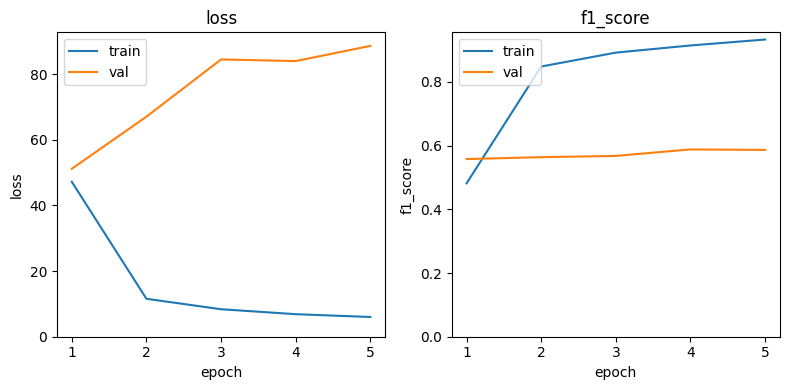

In [58]:
plot_model_history(vgg16_pre_trained_model_history, ["loss", "f1_score"])

using image size (512, 512), no dropout, no augmentation, flatten

In [27]:
vgg16_pre_trained_model_history = vgg16_pre_trained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)
)

Epoch 1/10
2334/2335 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - categorical_accuracy: 0.4562 - f1_score: 0.4276 - loss: 95.4653

2026-04-21 13:44:58.964275: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-21 13:44:59.976656: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 32.52GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-21 13:45:00.350184: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.33GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-21 13:45:01.358610: W external/local_xla/xla

2335/2335 ━━━━━━━━━━━━━━━━━━━━ 482s 205ms/step - categorical_accuracy: 0.5463 - f1_score: 0.5164 - loss: 101.6040 - val_categorical_accuracy: 0.6337 - val_f1_score: 0.6109 - val_loss: 112.3538
Epoch 2/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 495s 212ms/step - categorical_accuracy: 0.9058 - f1_score: 0.9025 - loss: 20.6045 - val_categorical_accuracy: 0.6472 - val_f1_score: 0.6288 - val_loss: 133.5641
Epoch 3/10
2335/2335 ━━━━━━━━━━━━━━━━━━━━ 471s 202ms/step - categorical_accuracy: 0.9437 - f1_score: 0.9421 - loss: 11.0113 - val_categorical_accuracy: 0.6337 - val_f1_score: 0.6106 - val_loss: 182.8824


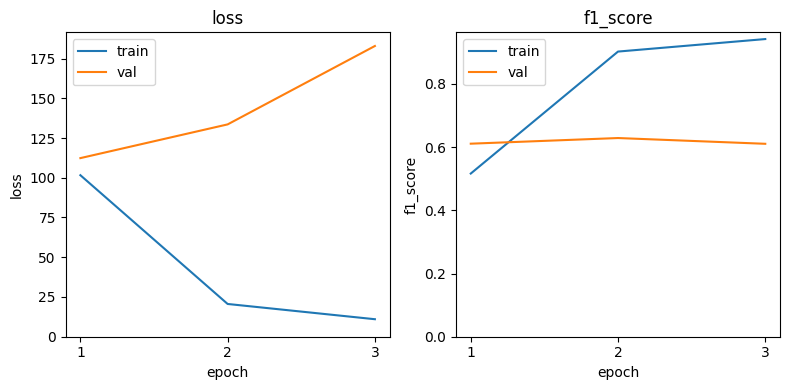

In [50]:
plot_model_history(vgg16_pre_trained_model_history, ["loss", "f1_score"])

## 3. ResNet

## 4. MobileNet

## 5. EfficientNet

## 6. ConvNeXt

## 7. Comparing fine-tuning a smaller model with not fine-tuning a large model

## 8. Final Model and Evaluation